# Scenario-analysis throughput: mSWE-GNN (batched, GPU) vs SFINCS (multi-process, CPU)

`measure_ahr_inference_timing_gpu.ipynb` times **one** scenario at a time (batch size 1) and
finds only a 1.1-1.8x speed-up, because at batch size 1 fixed GPU/Python/Lightning overhead
dominates. That notebook answers "how fast is a single forecast"; it does not answer the
professor's question, which is about **scenario analysis / optimization**, i.e. running many
independent simulations at once (a discharge-scaling ensemble, a Monte-Carlo sweep, an
optimization inner loop).

For that use case the GNN has a capability SFINCS structurally lacks: B independent scenarios
can be stacked into a single `torch_geometric.data.Batch` and solved in **one** GPU forward
pass, so cost grows sub-linearly with B. SFINCS has no equivalent -- each scenario is a
separate solver process, parallelizable only across CPU cores/nodes, never batched into one
solve. This notebook measures that gap directly.

**GNN side (measured):** for B in {1, 2, 4, 8, ...}, sample B of the 6 already-available
full-rollout scenario graphs (`q050`...`q300`, with replacement), batch them, and time one
`trainer.predict()` call with `torch.cuda.synchronize()` around it. Stop when the batch OOMs.

**SFINCS side (analytical, from measured single-run times):** each run's `Total simulation
time` is already logged in `sfincs.log` (same numbers used in the GPU timing notebook). SFINCS
gets **no concurrency benefit (P=1)**: it runs locally on a 4-core Windows VM that already uses
all 4 threads per run, so there's no spare capacity for a second instance. We tried porting it
to hal8 (2026-09-05) via Apptainer + the official `deltares/sfincs-cpu` Docker image, which
would have given real concurrency on the `4vcpu` partition (19 nodes, `sinfo -p 4vcpu`) -- but
both `sfincs-v2.3.0-mt-Faber-Release` and the newer `sfincs-v2.3.3` segfault deterministically
at ~95-100% completion on this domain (same crash regardless of thread count, `storevel`, or
stack-size settings), so no working Linux build exists for this model yet. B scenarios
therefore cost `B * avg_time`, with no relief from parallelism at all -- if anything this
understates the GNN's real-world advantage for scenario analysis.

Mesh-building time is excluded on both sides, same convention as the other timing notebooks.

In [1]:
import os, sys
REPO_ROOT = os.path.dirname(os.getcwd())
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

import time
import random
import torch
import wandb
import lightning as L
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
random.seed(0)

N_THREADS = int(os.environ.get('SLURM_CPUS_PER_TASK', 4))
os.environ['OMP_NUM_THREADS'] = str(N_THREADS)
torch.set_num_threads(N_THREADS)
torch.set_num_interop_threads(1)

CONFIG     = 'config_best_sweep_multisim.yaml'
CHECKPOINT = os.path.join(REPO_ROOT, 'results', 'best_sweep_multisim.h5')

# tag -> (test dataset name, SFINCS "Total simulation time" [s] from sfincs.log)
# same 6 scenarios/timings as measure_ahr_inference_timing_gpu.ipynb
SCENARIOS = {
    'q050': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q050', 7.503),
    'q075': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q075', 8.307),
    'q125': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q125', 9.502),
    'q150': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q150', 10.636),
    'q200': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q200', 10.824),
    'q300': ('ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_q300', 13.170),
}
AVG_SFINCS_TIME = sum(t for _, t in SCENARIOS.values()) / len(SCENARIOS)

# SFINCS concurrency: no working Linux build exists yet (segfaults on hal8, see markdown
# above), and the local Windows VM already uses all 4 of its 4 threads per run -- so there
# is no spare capacity anywhere to run a second scenario concurrently. P=1 is not a
# simplifying assumption, it's the measured reality; revisit if the hal8 crash gets fixed.
P_CONCURRENT_SFINCS = 1

# Batch sizes to sweep; the loop stops early on CUDA OOM.
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
assert device.type == 'cuda', 'No GPU visible -- submit via run_measure_ahr_scenario_scaling_gpu_hal8.sh (partition=gpu)'

Device: cuda


## Load model once

In [2]:
cfg = read_config(CONFIG)
wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)
temporal_dataset_probe = to_temporal_dataset(test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters)
num_node_features = temporal_dataset_probe[0].x.size(-1)
num_edge_features = temporal_dataset_probe[0].edge_attr.size(-1)

model_parameters = dict(config.models)
model_type = model_parameters.pop('model_type')
if model_type == 'MSGNN':
    model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

_ckpt = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
_sd = _ckpt['state_dict']
_hid = _sd['model.edge_encoder.0.weight'].shape[0]

_proc_ids = sorted(set(
    int(k.split('.')[2]) for k in _sd
    if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
))
_K_list = [
    sum(1 for k in _sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
    for i in _proc_ids
]
if _hid != model_parameters.get('hid_features') or _K_list != model_parameters.get('K'):
    print(f'Checkpoint arch override: hid_features={_hid}, K={_K_list}')
    model_parameters['hid_features'] = _hid
    model_parameters['K'] = _K_list

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters['previous_t'],
    device=device,
    **model_parameters
).to(device)

plmodule = LightningTrainer.load_from_checkpoint(
    CHECKPOINT, map_location=device,
    model=model,
    lr_info=config['lr_info'],
    trainer_options=config.trainer_options,
    temporal_test_dataset_parameters=temporal_test_dataset_parameters
)
model = plmodule.model.to(device)
model.eval()
print(f'Model loaded -- epoch {_ckpt["epoch"]}')

trainer = L.Trainer(accelerator='gpu', devices=1, logger=False,
                     enable_progress_bar=False, enable_checkpointing=False)

The validation dataset you are using is the training one. Careful!


/u/marrocol/.conda/envs/mswe-gnn/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:55: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


Model loaded -- epoch 741


## Build the scenario pool

Each of the 6 scenarios becomes exactly one full-rollout `Data` object (`rollout_steps=-1`),
matching what `measure_ahr_inference_timing_gpu.ipynb` times per scenario. This is the pool we
sample from (with replacement) to build batches of B independent "parallel simulations".

In [3]:
pool = []
for tag, (dataset_name, sfincs_time) in SCENARIOS.items():
    cfg_i = read_config(CONFIG)
    cfg_i['dataset_parameters']['test_dataset_name'] = dataset_name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg_i)
    fix_dict_in_config(wandb)
    config_i = wandb.config

    _, _, test_dataset_i, _ = create_model_dataset(
        scalers=config_i.scalers, device=device,
        **config_i.dataset_parameters,
        **config_i.selected_node_features,
        **config_i.selected_edge_features
    )
    temporal_test_dataset = to_temporal_dataset(
        test_dataset_i, rollout_steps=-1, **temporal_test_dataset_parameters
    )
    assert len(temporal_test_dataset) == 1, 'Expected exactly one full-rollout graph per scenario'
    pool.append((tag, temporal_test_dataset[0]))
    print(f'{tag}: loaded (SFINCS={sfincs_time:.3f}s)')

# Batch.from_data_list requires every graph in a batch to share the same attribute keys.
# Some scenarios carry the optional 'node_BC_outflow' (outflow ghost cells) and others
# don't, which breaks collation when a batch mixes them. Irrelevant to pure forward-pass
# timing, so drop it from every graph to make the pool uniformly batchable.
for _, g in pool:
    if 'node_BC_outflow' in g.keys():
        del g.node_BC_outflow

print(f'\nPool size: {len(pool)} unique scenario graphs')

The validation dataset you are using is the training one. Careful!
q050: loaded (SFINCS=7.503s)


The validation dataset you are using is the training one. Careful!
q075: loaded (SFINCS=8.307s)


The validation dataset you are using is the training one. Careful!
q125: loaded (SFINCS=9.502s)


The validation dataset you are using is the training one. Careful!
q150: loaded (SFINCS=10.636s)


The validation dataset you are using is the training one. Careful!
q200: loaded (SFINCS=10.824s)


The validation dataset you are using is the training one. Careful!
q300: loaded (SFINCS=13.170s)

Pool size: 6 unique scenario graphs


## Warm-up

Untimed: the first `trainer.predict()` call eats one-time CUDA/Lightning setup overhead that
would otherwise unfairly inflate whichever batch size runs first.

In [4]:
warmup_graphs = [g for _, g in pool][:2]
warmup_dataloader = DataLoader(warmup_graphs, batch_size=len(warmup_graphs), shuffle=False)
trainer.predict(plmodule, dataloaders=warmup_dataloader)
torch.cuda.synchronize()
print('Warm-up predict done.')

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


SLURM auto-requeueing enabled. Setting signal handlers.


/u/marrocol/.conda/envs/mswe-gnn/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Warm-up predict done.


## Time batched GNN inference vs batch size B

In [5]:
results = []  # (B, gnn_total_time, gnn_per_scenario_time)
graphs_only = [g for _, g in pool]

for B in BATCH_SIZES:
    batch_graphs = random.choices(graphs_only, k=B)
    dataloader = DataLoader(batch_graphs, batch_size=B, shuffle=False)

    try:
        torch.cuda.synchronize()
        start_time = time.time()
        trainer.predict(plmodule, dataloaders=dataloader)
        torch.cuda.synchronize()
        elapsed = time.time() - start_time
    except torch.cuda.OutOfMemoryError:
        print(f'B={B}: CUDA OOM -- stopping sweep here')
        torch.cuda.empty_cache()
        break

    per_scenario = elapsed / B
    results.append((B, elapsed, per_scenario))
    print(f'B={B:5d}  total={elapsed:8.4f}s  per-scenario={per_scenario:.5f}s  throughput={B/elapsed:.1f} scenarios/s')

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


SLURM auto-requeueing enabled. Setting signal handlers.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


SLURM auto-requeueing enabled. Setting signal handlers.


B=    1  total=  1.4607s  per-scenario=1.46066s  throughput=0.7 scenarios/s


...

B=   64  total= 29.6253s  per-scenario=0.46290s  throughput=2.2 scenarios/s


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


SLURM auto-requeueing enabled. Setting signal handlers.


B=  128  total= 59.1789s  per-scenario=0.46234s  throughput=2.2 scenarios/s


B=256: CUDA OOM -- stopping sweep here


## Compare against SFINCS and plot

In [6]:
import math

# P_CONCURRENT_SFINCS=1 means "serial" and "concurrent" collapse to the same number --
# that's the actual finding (no concurrency available anywhere), not a coincidence.
print(f'{"B":>6s}{"GNN [s]":>12s}{"SFINCS [s] (P=1)":>18s}{"speed-up":>12s}')
table = []
for B, gnn_total, _ in results:
    sfincs_time = math.ceil(B / P_CONCURRENT_SFINCS) * AVG_SFINCS_TIME
    speedup = sfincs_time / gnn_total
    table.append((B, gnn_total, sfincs_time, speedup))
    print(f'{B:6d}{gnn_total:12.4f}{sfincs_time:18.1f}{speedup:12.1f}')

     B     GNN [s]  SFINCS [s] (P=1)    speed-up
     1      1.4607              10.0         6.8
     2      1.8324              20.0        10.9
     4      2.6268              40.0        15.2
     8      4.3641              79.9        18.3
    16      7.8398             159.8        20.4
    32     14.9374             319.7        21.4
    64     29.6253             639.4        21.6
   128     59.1789            1278.8        21.6


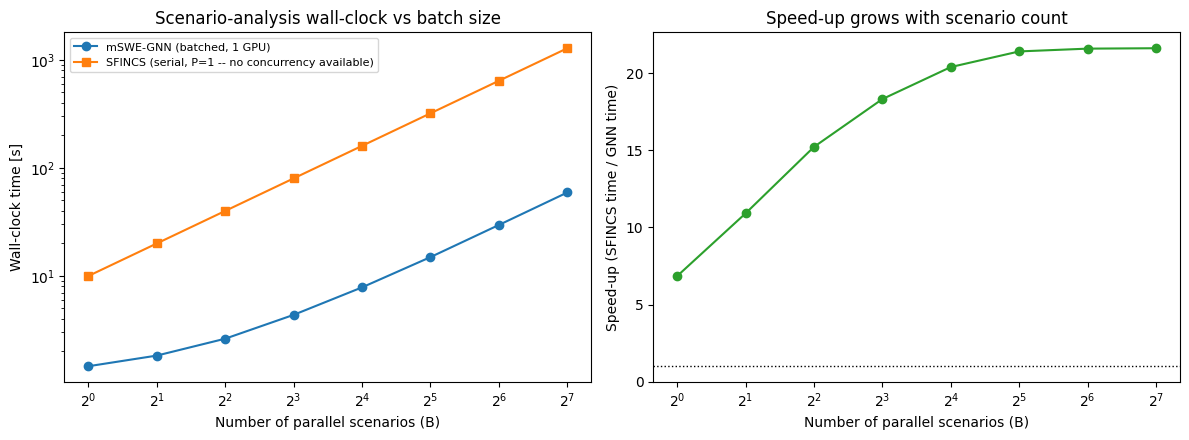

In [7]:
Bs = [r[0] for r in table]
gnn_times = [r[1] for r in table]
sfincs_times = [r[2] for r in table]
speedups = [r[3] for r in table]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(Bs, gnn_times, marker='o', label='mSWE-GNN (batched, 1 GPU)')
ax.plot(Bs, sfincs_times, marker='s', label='SFINCS (serial, P=1 -- no concurrency available)')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('Number of parallel scenarios (B)')
ax.set_ylabel('Wall-clock time [s]')
ax.set_title('Scenario-analysis wall-clock vs batch size')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(Bs, speedups, marker='o', color='tab:green')
ax.axhline(1, color='k', linestyle=':', linewidth=1)
ax.set_xscale('log', base=2)
ax.set_xlabel('Number of parallel scenarios (B)')
ax.set_ylabel('Speed-up (SFINCS time / GNN time)')
ax.set_title('Speed-up grows with scenario count')

plt.tight_layout()
plt.savefig('scenario_scaling_speedup.png', dpi=150)
plt.show()